In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
data = pd.read_csv("adult_census_income.csv")

| Feature        | Description                                                           |
|----------------|------------------------------------------------------------------------|
| **age**        | Age of the individual (numeric)                                       |
| **workclass**  | Type of employer (e.g., private, self-employed, government)           |
| **fnlwgt**     | Census final weight; how many people this record represents           |
| **education**  | Highest education level achieved (categorical)                        |
| **education.num** | Numeric code for education level (years of schooling)               |
| **marital.status** | Marital situation (e.g., married, never married, divorced)         |
| **occupation** | Job category (e.g., sales, tech, farming)                             |
| **relationship** | Family role within a household (e.g., husband, wife, not-in-family)  |
| **race**       | Race of the individual (categorical)                                  |
| **sex**        | Gender of the individual (male or female)                              |
| **capital.gain** | Money gained from investments (numeric)                              |
| **capital.loss** | Money lost from investments (numeric)                                |
| **hours.per.week** | Number of working hours per week                                   |
| **native.country** | Country of origin                                                 |
| **income**     | Target label; whether income >50K or <=50K per year                   |


In [147]:
data

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [149]:
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [150]:
data.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)

In [151]:
data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [152]:
data["age"].unique()

array([90, 82, 66, 54, 41, 34, 38, 74, 68, 45, 52, 32, 51, 46, 57, 22, 37,
       29, 61, 21, 33, 49, 23, 59, 60, 63, 53, 44, 43, 71, 48, 73, 67, 40,
       50, 42, 39, 55, 47, 31, 58, 62, 36, 72, 78, 83, 26, 70, 27, 35, 81,
       65, 25, 28, 56, 69, 20, 30, 24, 64, 75, 19, 77, 80, 18, 17, 76, 79,
       88, 84, 85, 86, 87])

In [153]:
data["workclass"].unique()

array([nan, 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

In [154]:
data["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [155]:
data[data['workclass'].isna()]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
14,51,NaN,172175,Doctorate,16,Never-married,NaN,Not-in-family,White,Male,0,2824,40,United-States,>50K
24,61,NaN,135285,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,2603,32,United-States,<=50K
44,71,NaN,100820,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,2489,15,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,NaN,320084,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
32534,30,NaN,33811,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32541,71,NaN,287372,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
32543,41,NaN,202822,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [156]:
data['workclass'] = data['workclass'].fillna('Unknown')

In [157]:
data['workclass'] = data['workclass'].replace({
    'Private': 'Private',
    'Self-emp-not-inc': 'Self-employed',
    'Self-emp-inc': 'Self-employed',
    'Local-gov': 'Government',
    'State-gov': 'Government',
    'Federal-gov': 'Government',
    'Without-pay': 'Never-worked',
    'Never-worked': 'Never-worked',
    'Unknown': 'Unknown'
})

In [158]:
data["workclass"].value_counts()

workclass
Private          22696
Government        4351
Self-employed     3657
Unknown           1836
Never-worked        21
Name: count, dtype: int64

In [159]:
data["fnlwgt"].unique()

array([ 77053, 132870, 186061, ...,  34066,  84661, 257302],
      shape=(21648,))

In [160]:
data["education"].unique()

array(['HS-grad', 'Some-college', '7th-8th', '10th', 'Doctorate',
       'Prof-school', 'Bachelors', 'Masters', '11th', 'Assoc-acdm',
       'Assoc-voc', '1st-4th', '5th-6th', '12th', '9th', 'Preschool'],
      dtype=object)

In [161]:
data["education"].value_counts()

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

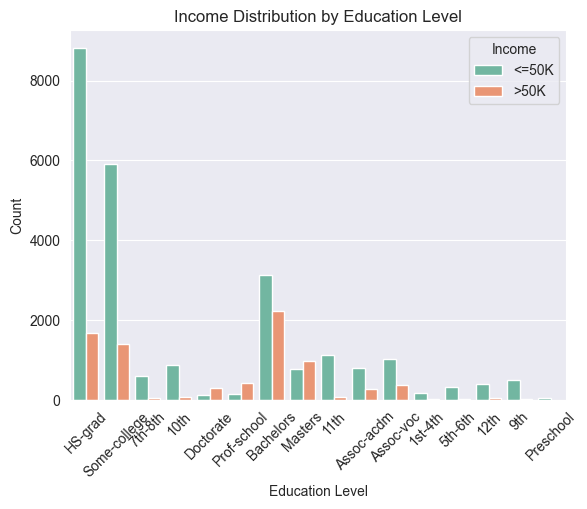

In [162]:
sns.countplot(x='education', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [163]:
data['education'] = data['education'].replace(
    {
    'Preschool': 'Pre High School',
    '1st-4th': 'Pre High School',
    '5th-6th': 'Pre High School',
    '7th-8th': 'Pre High School',
    '9th': 'High School',
    '10th': 'High School',
    '11th': 'High School',
    '12th': 'High School',
    'HS-grad': 'High School',
    'Some-college': 'College',
    'Assoc-acdm': 'College',
    'Assoc-voc': 'College',
    'Bachelors': 'Bachelors',
    'Masters': 'Masters',
    'Prof-school': 'Advanced',
    'Doctorate': 'Advanced'
}
)

In [164]:
data["education"].value_counts()

education
High School        13556
College             9740
Bachelors           5355
Masters             1723
Pre High School     1198
Advanced             989
Name: count, dtype: int64

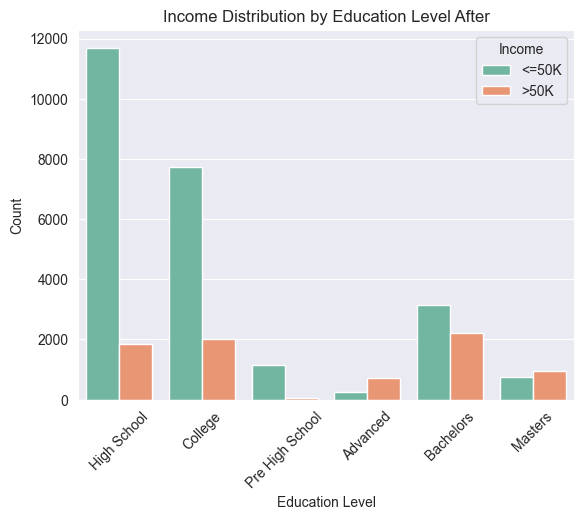

In [165]:
sns.countplot(x='education', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Education Level After')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [166]:
data["education.num"].unique()

array([ 9, 10,  4,  6, 16, 15, 13, 14,  7, 12, 11,  2,  3,  8,  5,  1])

In [167]:
data["education.num"].value_counts()

education.num
9     10501
10     7291
13     5355
14     1723
11     1382
7      1175
12     1067
6       933
4       646
15      576
5       514
8       433
16      413
3       333
2       168
1        51
Name: count, dtype: int64

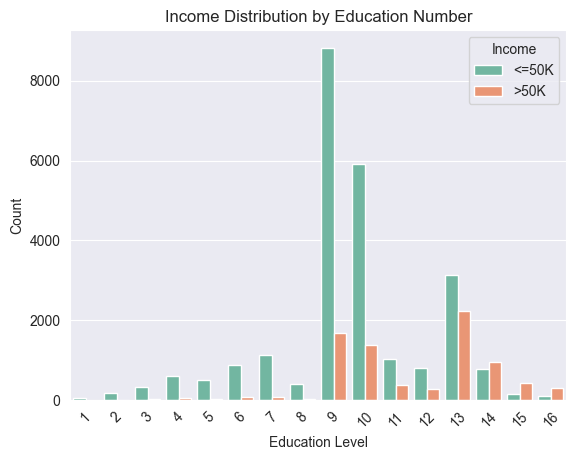

In [168]:
sns.countplot(x='education.num', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Education Number')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [169]:
data["marital.status"].unique()

array(['Widowed', 'Divorced', 'Separated', 'Never-married',
       'Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [170]:
data["marital.status"].value_counts()

marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

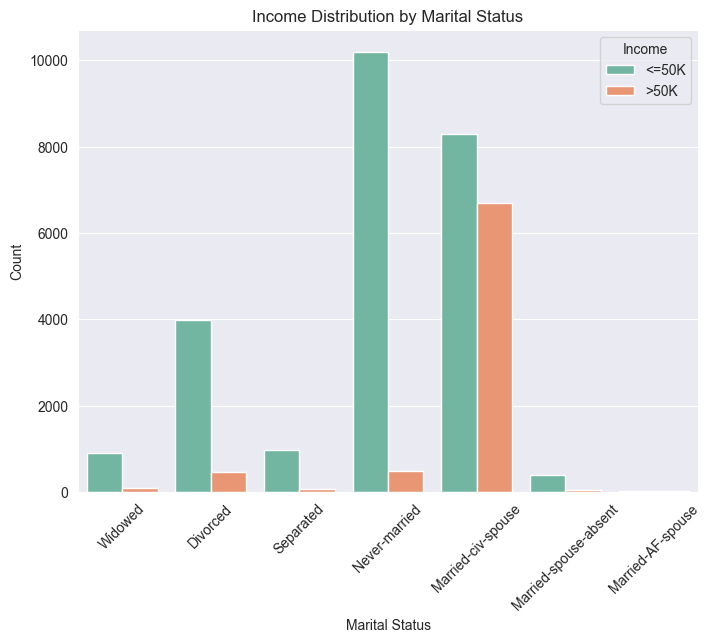

In [171]:
plt.figure(figsize=(8,6))
sns.countplot(x='marital.status', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [172]:
data['marital.status'] = data['marital.status'].replace({
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'Married',
    'Married-AF-spouse': 'Married',
    'Never-married': 'Single',
    'Divorced': 'Divorced/Separated',
    'Separated': 'Divorced/Separated',
    'Widowed': 'Widowed'
})

In [173]:
data["marital.status"].value_counts()

marital.status
Married               15417
Single                10683
Divorced/Separated     5468
Widowed                 993
Name: count, dtype: int64

In [174]:
data["occupation"].unique()

array([nan, 'Exec-managerial', 'Machine-op-inspct', 'Prof-specialty',
       'Other-service', 'Adm-clerical', 'Craft-repair',
       'Transport-moving', 'Handlers-cleaners', 'Sales',
       'Farming-fishing', 'Tech-support', 'Protective-serv',
       'Armed-Forces', 'Priv-house-serv'], dtype=object)

In [175]:
data[data['occupation'].isna()]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Unknown,77053,High School,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,66,Unknown,186061,College,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
14,51,Unknown,172175,Advanced,16,Single,NaN,Not-in-family,White,Male,0,2824,40,United-States,>50K
24,61,Unknown,135285,High School,9,Married,NaN,Husband,White,Male,0,2603,32,United-States,<=50K
44,71,Unknown,100820,High School,9,Married,NaN,Husband,White,Male,0,2489,15,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,Unknown,320084,Bachelors,13,Married,NaN,Wife,White,Female,0,0,55,United-States,>50K
32534,30,Unknown,33811,Bachelors,13,Single,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32541,71,Unknown,287372,Advanced,16,Married,NaN,Husband,White,Male,0,0,10,United-States,>50K
32543,41,Unknown,202822,High School,9,Divorced/Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [176]:
data['occupation'] = data['occupation'].fillna('Unknown')

In [177]:
data['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Unknown              1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

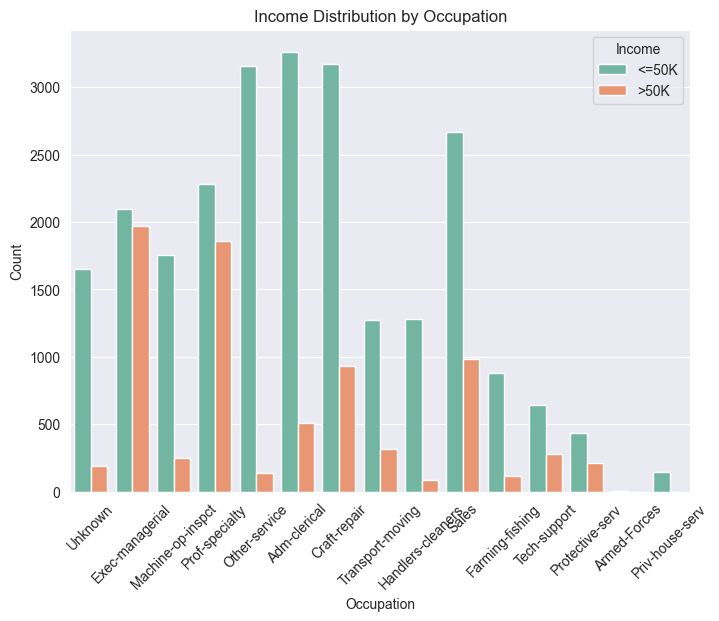

In [178]:
plt.figure(figsize=(8,6))
sns.countplot(x='occupation', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [179]:
data['occupation'] = data['occupation'].replace({
    'Exec-managerial': 'Executive/Professional',
    'Prof-specialty': 'Executive/Professional',
    'Craft-repair': 'Technical/Repair',
    'Machine-op-inspct': 'Technical/Repair',
    'Tech-support': 'Technical/Repair',
    'Adm-clerical': 'Administrative/Clerical',
    'Sales': 'Sales/Service',
    'Other-service': 'Sales/Service',
    'Handlers-cleaners': 'Sales/Service',
    'Transport-moving': 'Sales/Service',
    'Farming-fishing': 'Farming/Fishing',
    'Protective-serv': 'Protective/Armed',
    'Armed-Forces': 'Protective/Armed',
    'Priv-house-serv': 'Domestic'
})

In [180]:
data['occupation'].value_counts()

occupation
Sales/Service              9912
Executive/Professional     8206
Technical/Repair           7029
Administrative/Clerical    3770
Unknown                    1843
Farming/Fishing             994
Protective/Armed            658
Domestic                    149
Name: count, dtype: int64

In [181]:
data["relationship"].unique()

array(['Not-in-family', 'Unmarried', 'Own-child', 'Other-relative',
       'Husband', 'Wife'], dtype=object)

In [182]:
data["relationship"].value_counts()

relationship
Husband           13193
Not-in-family      8305
Own-child          5068
Unmarried          3446
Wife               1568
Other-relative      981
Name: count, dtype: int64

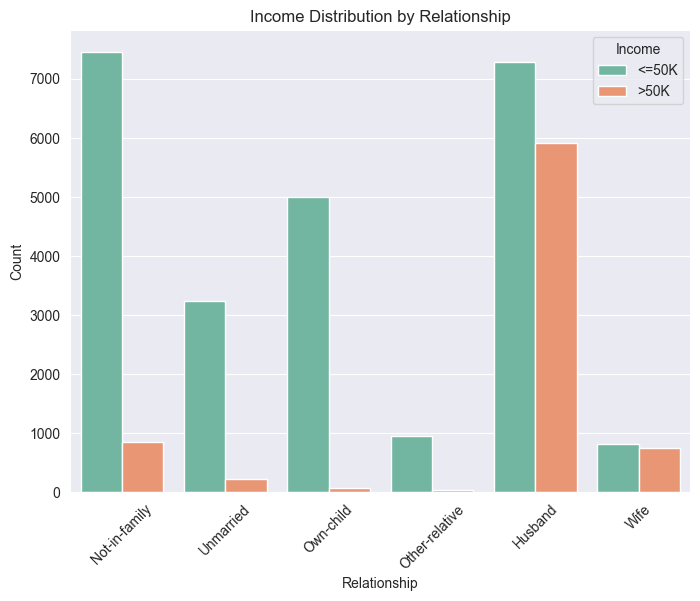

In [183]:
plt.figure(figsize=(8,6))
sns.countplot(x='relationship', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Relationship')
plt.xlabel('Relationship')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [184]:
data['relationship'] = data['relationship'].replace({
    'Husband': 'Family-Head',
    'Wife': 'Family-Head',
    'Not-in-family': 'Not-in-family',
    'Own-child': 'Child',
    'Unmarried': 'Unmarried',
    'Other-relative': 'Other-relative'
})

In [185]:
data["relationship"].value_counts()

relationship
Family-Head       14761
Not-in-family      8305
Child              5068
Unmarried          3446
Other-relative      981
Name: count, dtype: int64

In [186]:
data["race"].unique()

array(['White', 'Black', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], dtype=object)

In [187]:
data["race"].value_counts()

race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

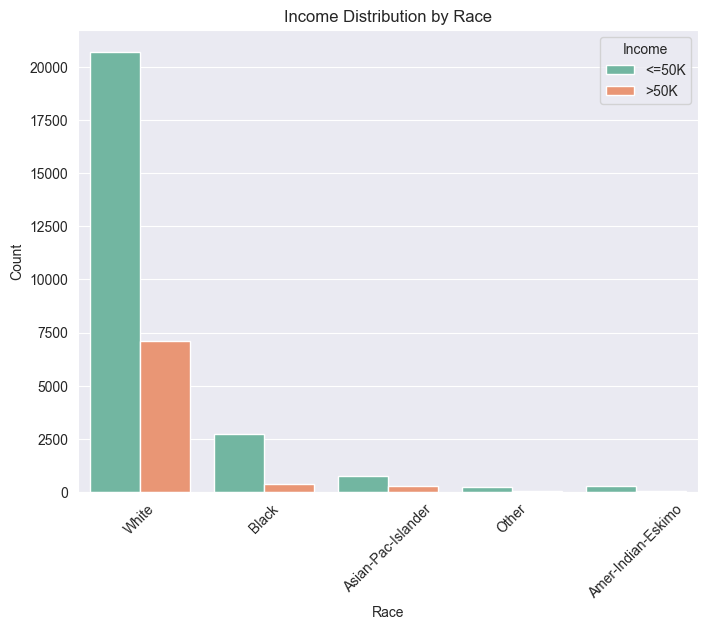

In [188]:
plt.figure(figsize=(8,6))
sns.countplot(x='race', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [189]:
data['race'] = data['race'].replace({
    'White': 'White',
    'Black': 'Black',
    'Asian-Pac-Islander': 'Other',
    'Amer-Indian-Eskimo': 'Other',
    'Other': 'Other'
})

In [190]:
data["race"].value_counts()

race
White    27816
Black     3124
Other     1621
Name: count, dtype: int64

In [191]:
data["sex"].unique()

array(['Female', 'Male'], dtype=object)

In [192]:
data["sex"].value_counts()

sex
Male      21790
Female    10771
Name: count, dtype: int64

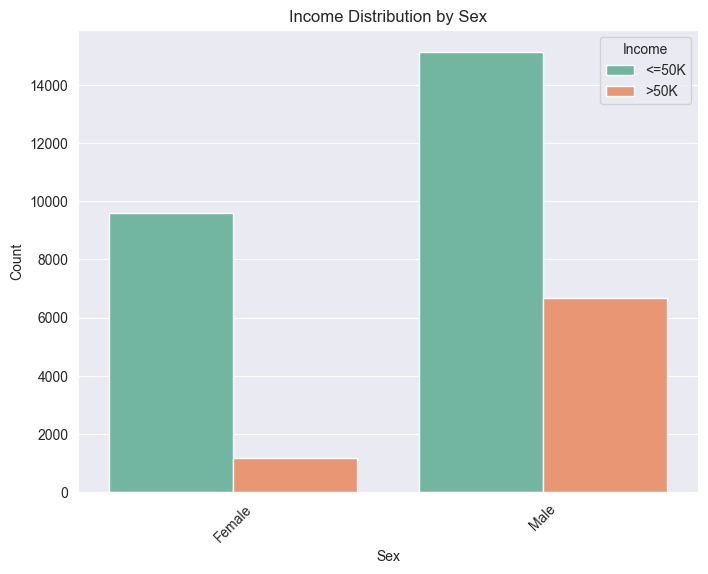

In [193]:
plt.figure(figsize=(8,6))
sns.countplot(x='sex', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [194]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [195]:
data["capital.gain"].unique()

array([    0, 99999, 41310, 34095, 27828, 25236, 25124, 22040, 20051,
       18481, 15831, 15024, 15020, 14344, 14084, 13550, 11678, 10605,
       10566, 10520,  9562,  9386,  8614,  7978,  7896,  7688,  7443,
        7430,  7298,  6849,  6767,  6723,  6514,  6497,  6418,  6360,
        6097,  5721,  5556,  5455,  5178,  5060,  5013,  4934,  4931,
        4865,  4787,  4687,  4650,  4508,  4416,  4386,  4101,  4064,
        3942,  3908,  3887,  3818,  3781,  3674,  3471,  3464,  3456,
        3432,  3418,  3411,  3325,  3273,  3137,  3103,  2993,  2977,
        2964,  2961,  2936,  2907,  2885,  2829,  2653,  2635,  2597,
        2580,  2538,  2463,  2414,  2407,  2387,  2354,  2346,  2329,
        2290,  2228,  2202,  2176,  2174,  2105,  2062,  2050,  2036,
        2009,  1848,  1831,  1797,  1639,  1506,  1471,  1455,  1424,
        1409,  1173,  1151,  1111,  1086,  1055,   991,   914,   594,
         401,   114])

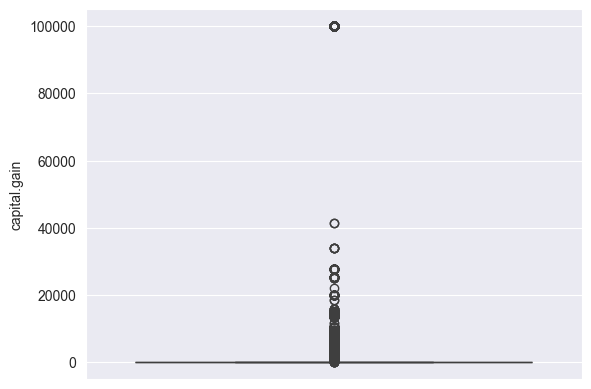

In [196]:
sns.boxplot(data["capital.gain"])
plt.show()

In [197]:
data["capital.loss"].unique()

array([4356, 3900, 3770, 3683, 3004, 2824, 2754, 2603, 2559, 2547, 2489,
       2472, 2467, 2457, 2444, 2415, 2392, 2377, 2352, 2339, 2282, 2267,
       2258, 2246, 2238, 2231, 2206, 2205, 2201, 2179, 2174, 2163, 2149,
       2129, 2080, 2057, 2051, 2042, 2002, 2001, 1980, 1977, 1974, 1944,
       1902, 1887, 1876, 1848, 1844, 1825, 1816, 1762, 1755, 1741, 1740,
       1735, 1726, 1721, 1719, 1672, 1669, 1668, 1651, 1648, 1628, 1617,
       1602, 1594, 1590, 1579, 1573, 1564, 1539, 1504, 1485, 1411, 1408,
       1380, 1340, 1258, 1138, 1092,  974,  880,  810,  653,  625,  419,
        323,  213,  155,    0])

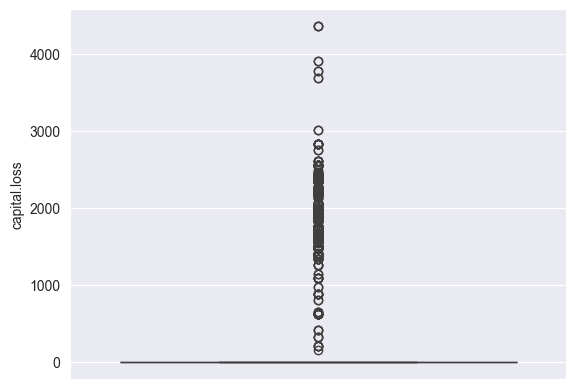

In [198]:
sns.boxplot(data["capital.loss"])
plt.show()

In [199]:
data['net_investment'] = data['capital.gain'] - data['capital.loss']

def investment_category(row):
    if row['capital.gain'] == 0 and row['capital.loss'] == 0:
        return 'No Investment'
    elif row['net_investment'] > 0:
        return 'Profit'
    else:
        return 'Loss'

data['investment_status'] = data.apply(investment_category, axis=1)

In [200]:
data['investment_status'].value_counts()

investment_status
No Investment    28330
Profit            2712
Loss              1519
Name: count, dtype: int64

In [201]:
data["hours.per.week"].unique()

array([40, 18, 45, 20, 60, 35, 55, 76, 50, 42, 25, 32, 90, 48, 15, 70, 52,
       72, 39,  6, 65, 12, 80, 67, 99, 30, 75, 26, 36, 10, 84, 38, 62, 44,
        8, 28, 59,  5, 24, 57, 34, 37, 46, 56, 41, 98, 43, 63,  1, 47, 68,
       54,  2, 16,  9,  3,  4, 33, 23, 22, 64, 51, 19, 58, 53, 96, 66, 21,
        7, 13, 27, 11, 14, 77, 31, 78, 49, 17, 85, 87, 88, 73, 89, 97, 94,
       29, 82, 86, 91, 81, 92, 61, 74, 95])

In [202]:
data["hours.per.week"].value_counts()

hours.per.week
40    15217
50     2819
45     1824
60     1475
35     1297
      ...  
87        1
94        1
82        1
92        1
74        1
Name: count, Length: 94, dtype: int64

In [203]:
data["hours.per.week"].describe()

count    32561.000000
mean        40.437456
std         12.347429
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours.per.week, dtype: float64

<Axes: ylabel='hours.per.week'>

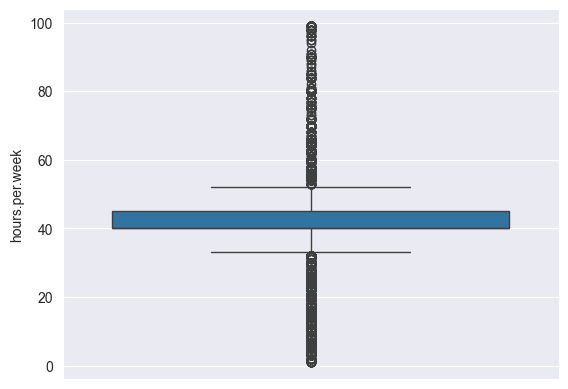

In [204]:
sns.boxplot(data["hours.per.week"])

In [205]:
bins = [0, 20, 35, 40, 50, 60, 100]
labels = ['Very Low','Low','Standard','Overtime','Heavy','Extreme']
data['hours_grouped'] = pd.cut(data['hours.per.week'], bins=bins, labels=labels)

In [206]:
data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,net_investment,investment_status,hours_grouped
0,90,Unknown,77053,High School,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K,-4356,Loss,Standard
1,82,Private,132870,High School,9,Widowed,Executive/Professional,Not-in-family,White,Female,0,4356,18,United-States,<=50K,-4356,Loss,Very Low
2,66,Unknown,186061,College,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K,-4356,Loss,Standard
3,54,Private,140359,Pre High School,4,Divorced/Separated,Technical/Repair,Unmarried,White,Female,0,3900,40,United-States,<=50K,-3900,Loss,Standard
4,41,Private,264663,College,10,Divorced/Separated,Executive/Professional,Child,White,Female,0,3900,40,United-States,<=50K,-3900,Loss,Standard


In [207]:
data["hours_grouped"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 32561 entries, 0 to 32560
Series name: hours_grouped
Non-Null Count  Dtype   
--------------  -----   
32561 non-null  category
dtypes: category(1)
memory usage: 32.1 KB


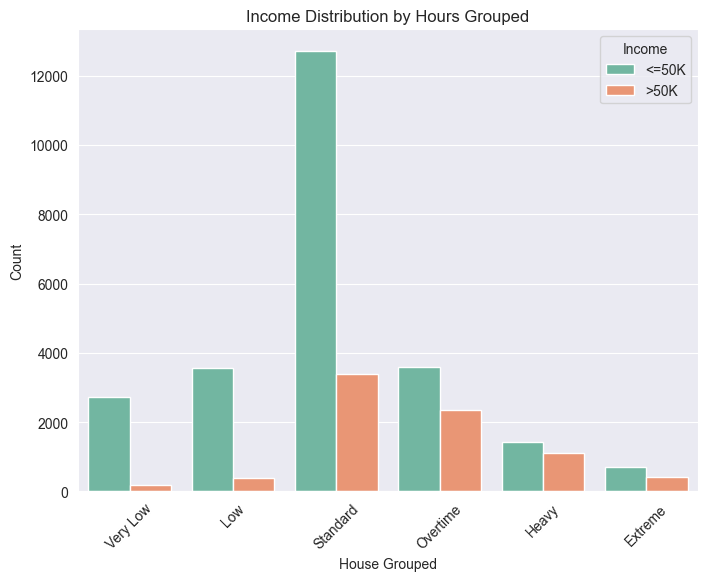

In [208]:
plt.figure(figsize=(8,6))
sns.countplot(x='hours_grouped', hue='income', data=data, palette='Set2')
plt.title('Income Distribution by Hours Grouped')
plt.xlabel('House Grouped')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [209]:
data["native.country"].unique()

array(['United-States', nan, 'Mexico', 'Greece', 'Vietnam', 'China',
       'Taiwan', 'India', 'Philippines', 'Trinadad&Tobago', 'Canada',
       'South', 'Holand-Netherlands', 'Puerto-Rico', 'Poland', 'Iran',
       'England', 'Germany', 'Italy', 'Japan', 'Hong', 'Honduras', 'Cuba',
       'Ireland', 'Cambodia', 'Peru', 'Nicaragua', 'Dominican-Republic',
       'Haiti', 'El-Salvador', 'Hungary', 'Columbia', 'Guatemala',
       'Jamaica', 'Ecuador', 'France', 'Yugoslavia', 'Scotland',
       'Portugal', 'Laos', 'Thailand', 'Outlying-US(Guam-USVI-etc)'],
      dtype=object)

In [210]:
data["native.country"].isnull().sum()

np.int64(583)

In [211]:
data[data['native.country'].isna()]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,net_investment,investment_status,hours_grouped
9,41,Private,70037,College,10,Single,Technical/Repair,Unmarried,White,Male,0,3004,60,NaN,>50K,-3004,Loss,Heavy
18,22,Private,119592,College,12,Single,Sales/Service,Not-in-family,Black,Male,0,2824,40,NaN,>50K,-2824,Loss,Standard
65,60,Self-employed,226355,College,11,Married,Technical/Repair,Family-Head,White,Male,0,2415,70,NaN,>50K,-2415,Loss,Extreme
86,39,Self-employed,218490,Advanced,15,Married,Executive/Professional,Family-Head,White,Male,0,2415,50,NaN,>50K,-2415,Loss,Overtime
87,43,Government,156996,Advanced,15,Married,Executive/Professional,Family-Head,Other,Male,0,2415,55,NaN,>50K,-2415,Loss,Heavy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32459,44,Self-employed,71556,Masters,14,Married,Sales/Service,Family-Head,White,Male,0,0,50,NaN,>50K,0,No Investment,Overtime
32476,58,Self-employed,181974,Advanced,16,Single,Executive/Professional,Not-in-family,White,Female,0,0,99,NaN,<=50K,0,No Investment,Extreme
32498,42,Self-employed,217597,High School,9,Divorced/Separated,Sales/Service,Child,White,Male,0,0,50,NaN,<=50K,0,No Investment,Overtime
32515,39,Private,107302,High School,9,Married,Executive/Professional,Family-Head,White,Male,0,0,45,NaN,>50K,0,No Investment,Overtime


In [212]:
data['native.country'] = data['native.country'].fillna('Unknown')

In [213]:
data['native.country'].value_counts()

native.country
United-States                 29170
Mexico                          643
Unknown                         583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece       

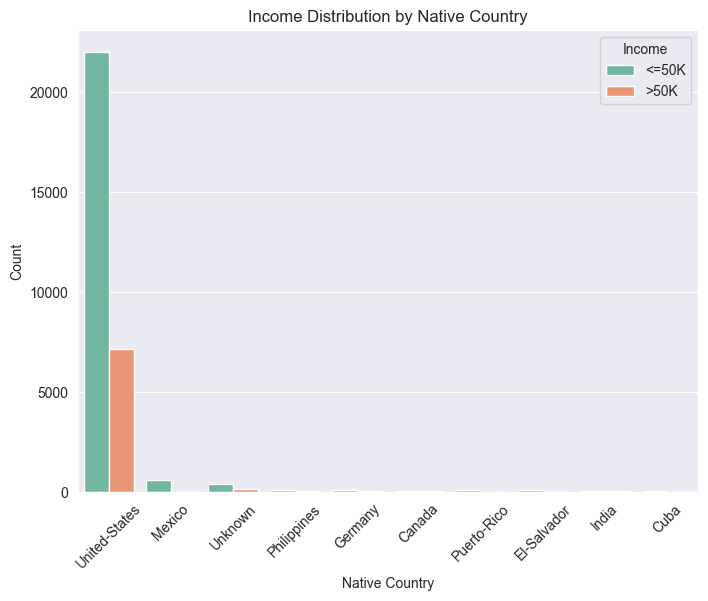

In [214]:
plt.figure(figsize=(8,6))
top10_countries = data['native.country'].value_counts().nlargest(10).index
sns.countplot(x='native.country', hue='income', data=data, palette='Set2', order=top10_countries)
plt.title('Income Distribution by Native Country')
plt.xlabel('Native Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

In [215]:
def country(x):
    if x == 'United-States':
        return 'United-States'
    elif x == 'Unknown':
        return 'Unknown'
    else:
        return 'Other'

data['native.country'] = data['native.country'].apply(country)
data['native.country'].value_counts()

native.country
United-States    29170
Other             2808
Unknown            583
Name: count, dtype: int64

In [216]:
data.isnull().sum()

age                  0
workclass            0
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation           0
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country       0
income               0
net_investment       0
investment_status    0
hours_grouped        0
dtype: int64

In [217]:
data["income"].unique()

array(['<=50K', '>50K'], dtype=object)

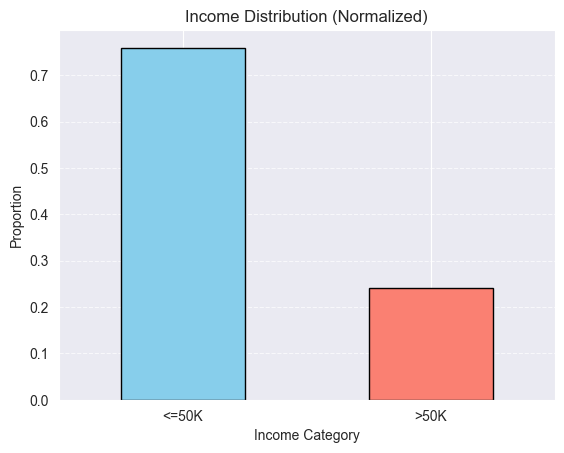

In [218]:
data["income"].value_counts(normalize=True).plot(
    kind="bar",
    color=["skyblue", "salmon"],
    edgecolor="black"
)

plt.title("Income Distribution (Normalized)")
plt.xlabel("Income Category")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [219]:
data['income'] = data['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [220]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                32561 non-null  int64   
 1   workclass          32561 non-null  object  
 2   fnlwgt             32561 non-null  int64   
 3   education          32561 non-null  object  
 4   education.num      32561 non-null  int64   
 5   marital.status     32561 non-null  object  
 6   occupation         32561 non-null  object  
 7   relationship       32561 non-null  object  
 8   race               32561 non-null  object  
 9   sex                32561 non-null  object  
 10  capital.gain       32561 non-null  int64   
 11  capital.loss       32561 non-null  int64   
 12  hours.per.week     32561 non-null  int64   
 13  native.country     32561 non-null  object  
 14  income             32561 non-null  int64   
 15  net_investment     32561 non-null  int64   
 16  inve

In [221]:
for col in data.columns:
    print(f"{col}: \n",data[col].unique())

age: 
 [90 82 66 54 41 34 38 74 68 45 52 32 51 46 57 22 37 29 61 21 33 49 23 59
 60 63 53 44 43 71 48 73 67 40 50 42 39 55 47 31 58 62 36 72 78 83 26 70
 27 35 81 65 25 28 56 69 20 30 24 64 75 19 77 80 18 17 76 79 88 84 85 86
 87]
workclass: 
 ['Unknown' 'Private' 'Government' 'Self-employed' 'Never-worked']
fnlwgt: 
 [ 77053 132870 186061 ...  34066  84661 257302]
education: 
 ['High School' 'College' 'Pre High School' 'Advanced' 'Bachelors'
 'Masters']
education.num: 
 [ 9 10  4  6 16 15 13 14  7 12 11  2  3  8  5  1]
marital.status: 
 ['Widowed' 'Divorced/Separated' 'Single' 'Married']
occupation: 
 ['Unknown' 'Executive/Professional' 'Technical/Repair' 'Sales/Service'
 'Administrative/Clerical' 'Farming/Fishing' 'Protective/Armed' 'Domestic']
relationship: 
 ['Not-in-family' 'Unmarried' 'Child' 'Other-relative' 'Family-Head']
race: 
 ['White' 'Black' 'Other']
sex: 
 ['Female' 'Male']
capital.gain: 
 [    0 99999 41310 34095 27828 25236 25124 22040 20051 18481 15831 15024
 15020 143

In [222]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income', 'net_investment', 'investment_status', 'hours_grouped'],
      dtype='object')

In [223]:
# Model

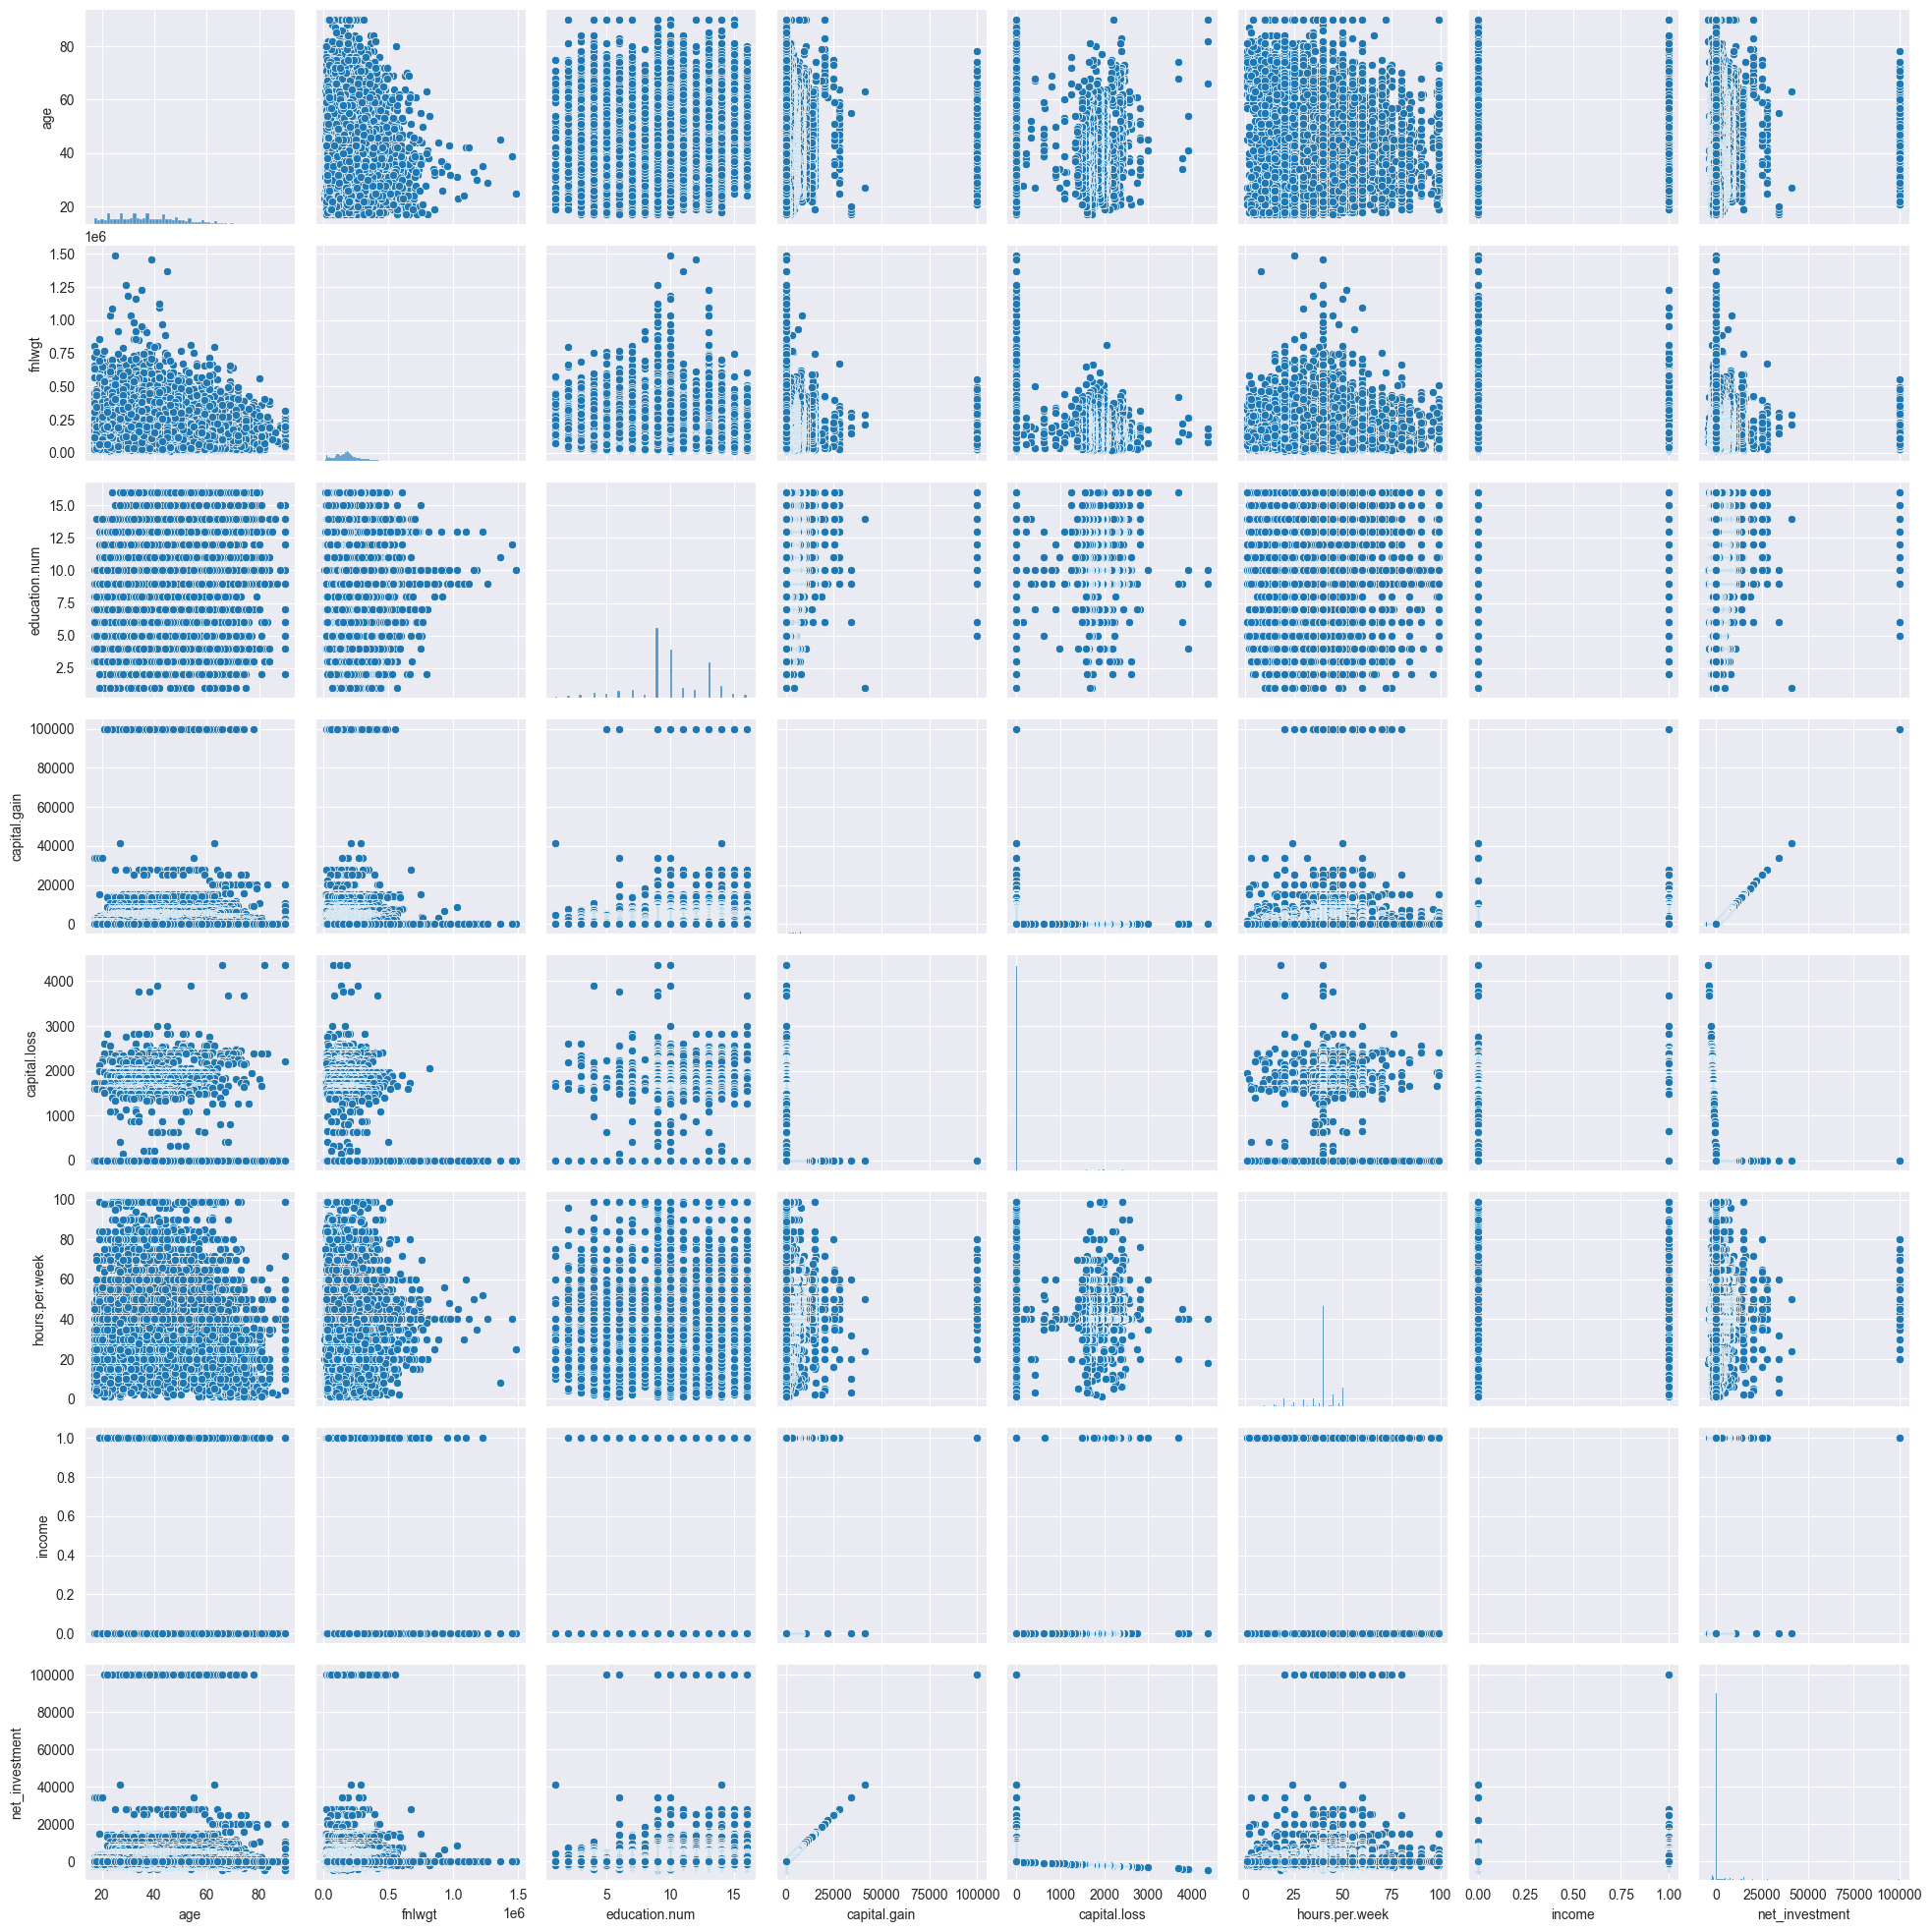

In [239]:
sns.pairplot(data)
plt.show()

In [249]:
X = data.drop(columns=["hours.per.week", "fnlwgt", "capital.gain", "capital.loss", "net_investment"])
y = data["hours.per.week"]

In [250]:
from sklearn.model_selection import train_test_split

In [251]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [252]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

ordinal_cols = ["education", "hours_grouped", "investment_status"]
ordinal_encoder = OrdinalEncoder(categories=[
    ["Pre High School", "High School", "College", "Bachelors", "Advanced", "Masters"],  # education
    ["Very Low", "Low", "Standard", "Overtime", "Heavy", "Extreme"],               # hours_grouped
    ["Loss", "No Investment", "Profit"] #investment_status
])

onehot_cols = ["workclass", "occupation", "relationship", "marital.status", "race", "sex", "native.country", "investment_status"]
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_cols),
        ("onehot", onehot_encoder, onehot_cols)
    ],
    remainder="passthrough"
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

In [258]:
from sklearn.tree import DecisionTreeRegressor

In [259]:
tree_model = DecisionTreeRegressor()
tree_model.fit(X_train_transformed, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [260]:
y_pred = tree_model.predict(X_test_transformed)

In [261]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [262]:
import warnings
warnings.filterwarnings("ignore")

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8804830752158872
Mean Squared Error: 17.6973308326277
Mean Absolute Error 2.1516964682996034


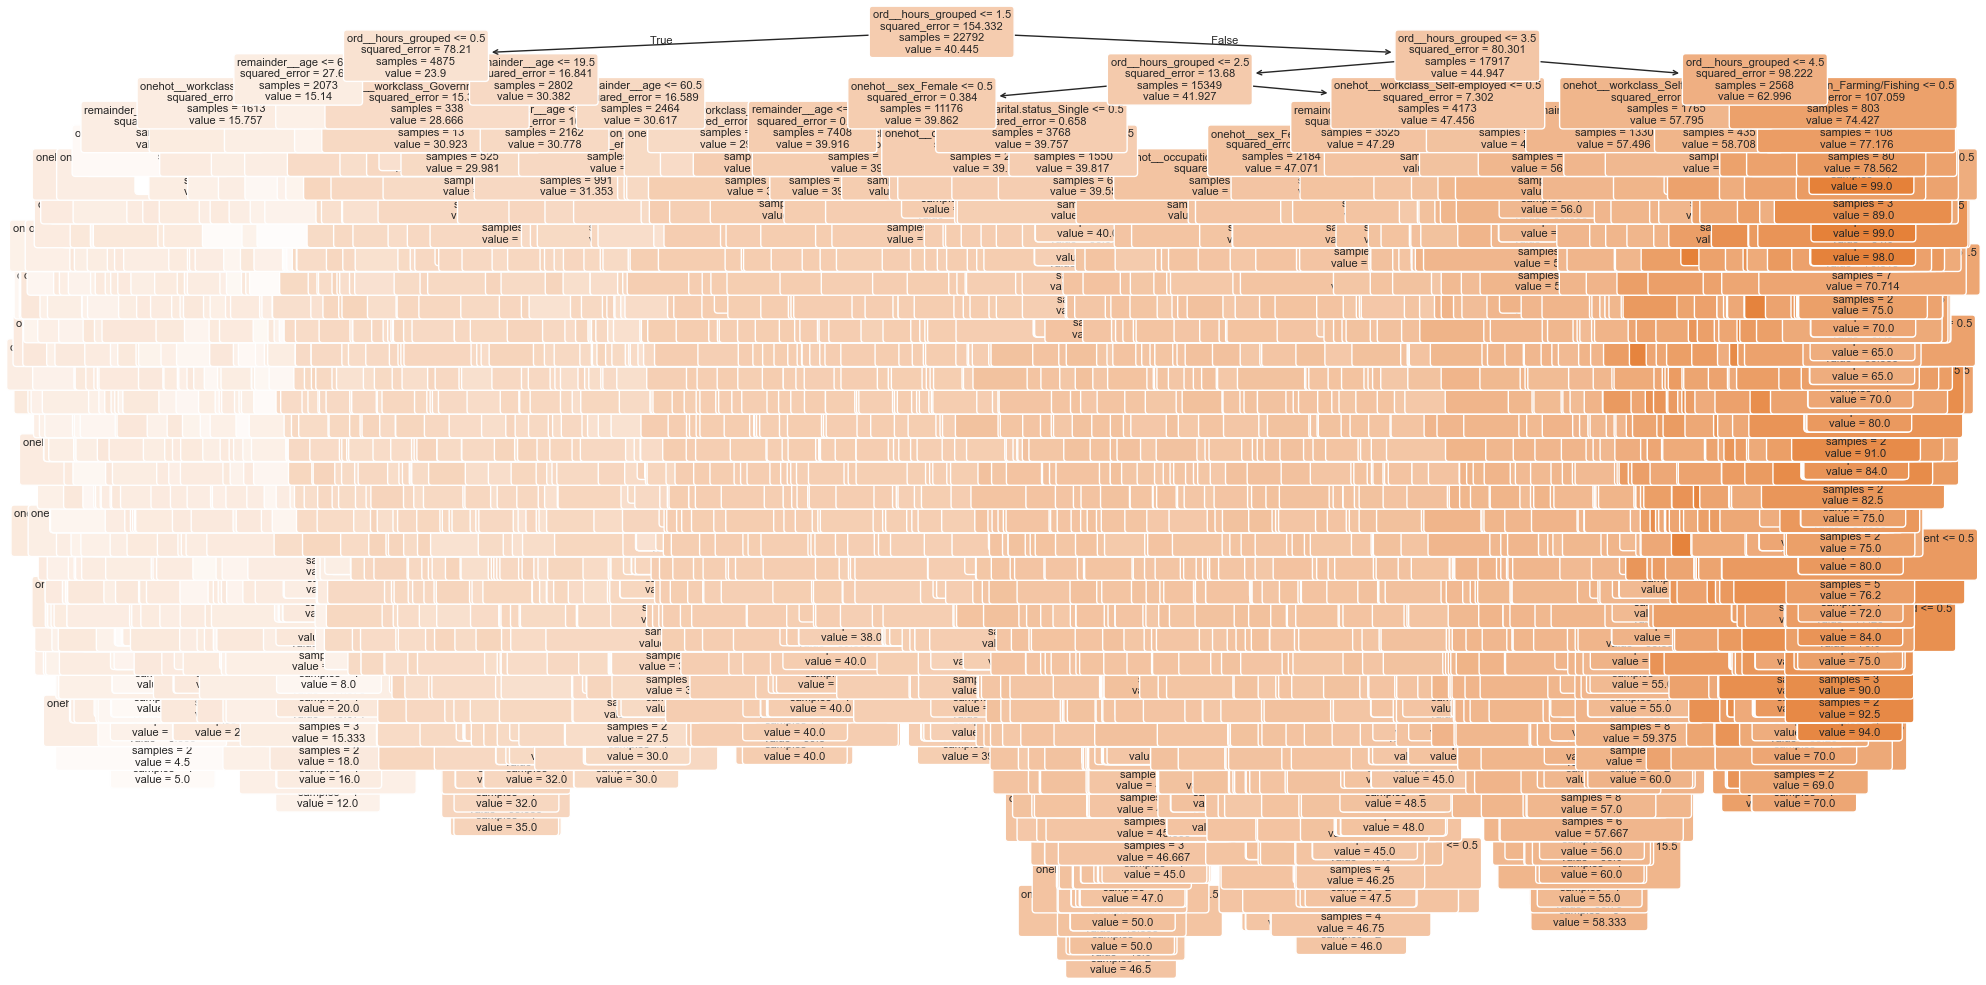

In [279]:
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(tree_model,
               feature_names=preprocessor.get_feature_names_out(),
               filled=True,
               rounded=True,
               fontsize=8)
plt.tight_layout()
plt.show()

In [283]:
y_train_pred = tree_model.predict(X_train_transformed)
y_test_pred = tree_model.predict(X_test_transformed)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2: ", r2_score(y_test, y_test_pred))

Train R2: 0.9931135064148497
Test R2:  0.8788951960421358


In [265]:
# hyperparameter tuning

In [266]:
param = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
    "splitter": ["best", "random"],
    "max_depth": [1,2,3,4,5,15, None],
    "max_features": ["sqrt", "log2", None],
}

In [267]:
from sklearn.model_selection import GridSearchCV

In [268]:
grid = GridSearchCV(estimator=DecisionTreeRegressor(), param_grid=param, cv=5, scoring="accuracy")

In [269]:
grid.fit(X_train_transformed, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'absolute_error'


In [270]:
grid.best_params_

{'criterion': 'absolute_error',
 'max_depth': 4,
 'max_features': None,
 'splitter': 'best'}

In [271]:
y_pred = grid.predict(X_test_transformed)

In [273]:
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9243239048939161
Mean Squared Error: 11.205650527177808
Mean Absolute Error 1.6916777561674685


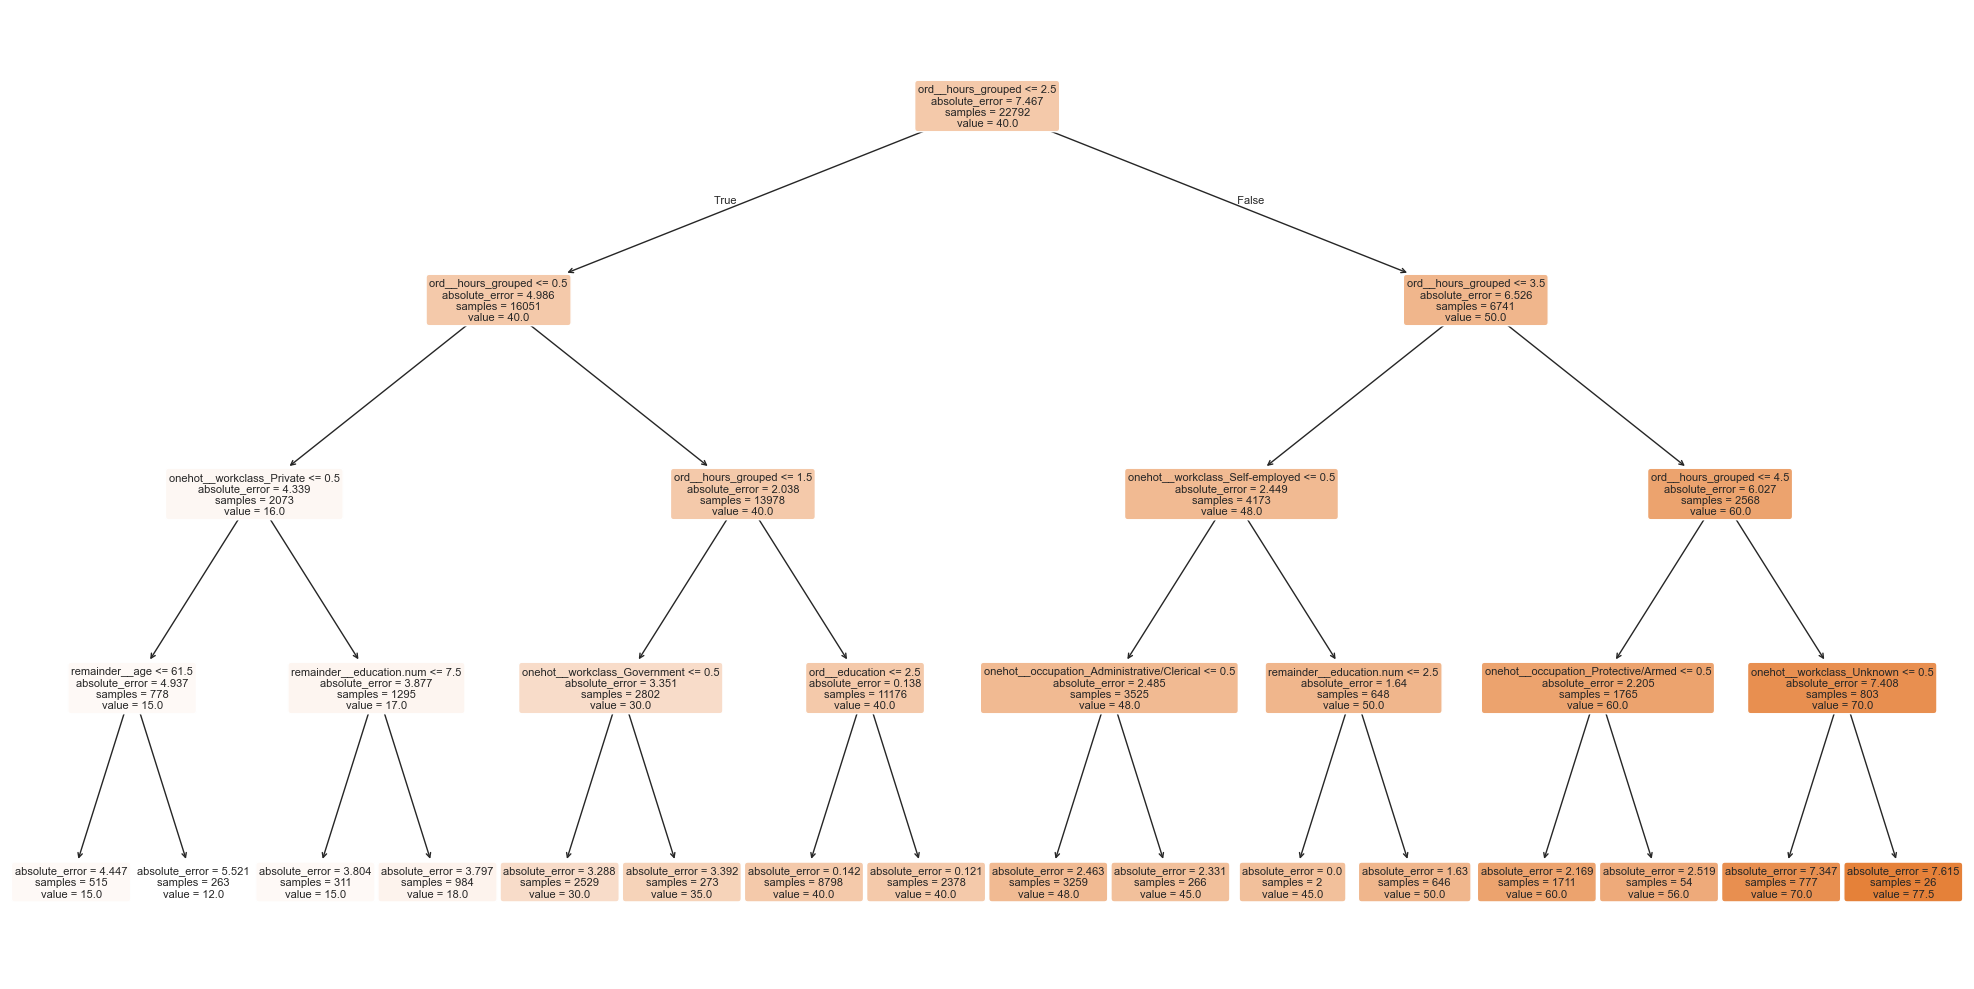

In [281]:
from sklearn import tree

best_tree = grid.best_estimator_

plt.figure(figsize=(20,10))
tree.plot_tree(best_tree,
               feature_names=preprocessor.get_feature_names_out(),
               filled=True,
               rounded=True,
               fontsize=8)
plt.tight_layout()
plt.show()

In [282]:
y_train_pred = best_tree.predict(X_train_transformed)
y_test_pred = best_tree.predict(X_test_transformed)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2: ", r2_score(y_test, y_test_pred))

Train R2: 0.9242972431385282
Test R2:  0.9243239048939161
